**Clasificación (Supervisado)**: ECG Hertbeat Categorization Data.

Este notebook tiene como objetivo el desarrollo y evaluación de un modelo de Deep Learning capaz de clasificar latidos cardíacos a partir de señales de Electrocardiograma (ECG). Utilizaremos el dataset MIT-BIH Arrhythmia Database.

**Metodología Aplicada**

Análisis Exploratorio (EDA)

Preprocesado y Balanceo de datos

uso de un modulo base ROCKET

Uso de una Arquitectura InceptionTime

Entrenamiento

Evaluación

Analisis tecnico de resultados





In [ ]:
pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import os
import kagglehub

# Descargar CSV directamente al almacenamiento local de Colab usando Kagglehub

path = kagglehub.dataset_download("shayanfazeli/heartbeat")

# para leer los ficheros (train, test):
train_df = pd.read_csv(os.path.join(path, 'mitbih_train.csv'), header=None)
test_df = pd.read_csv(os.path.join(path, 'mitbih_test.csv'), header=None)
print("✅ Archivos CSV listos y cargados")

Using Colab cache for faster access to the 'heartbeat' dataset.
✅ Archivos CSV listos y cargados


In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
import pytorch_lightning as pl
#import kagglehub


#path = kagglehub.dataset_download("shayanfazeli/heartbeat")

# DATAMODULE DE LIGHTNING ---
class MITBIHDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, batch_size=64):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size

    def setup(self, stage=None):
        # Construir las rutas usando el path de kagglehub
        train_path = os.path.join(self.data_dir, 'mitbih_train.csv')
        test_path = os.path.join(self.data_dir, 'mitbih_test.csv')

        # Carga de datos
        train_df = pd.read_csv(train_path, header=None)
        test_df = pd.read_csv(test_path, header=None)

        # X: todas las columnas menos la última
        X_train = train_df.iloc[:, :-1].values
        y_train = train_df.iloc[:, -1].values
        X_test = test_df.iloc[:, :-1].values
        y_test = test_df.iloc[:, -1].values

        # Reshape para convoluciones: (Samples, Channels, Length)
        X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
        X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

        # Conversión a Tensores
        self.train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
        self.test_ds = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size)

# Inicialización
dm = MITBIHDataModule(data_dir=path)
dm.setup()
print(f"Dataset listo en: {path}")

Dataset listo en: /kaggle/input/heartbeat


**Visualización de la Morfología del ECG**

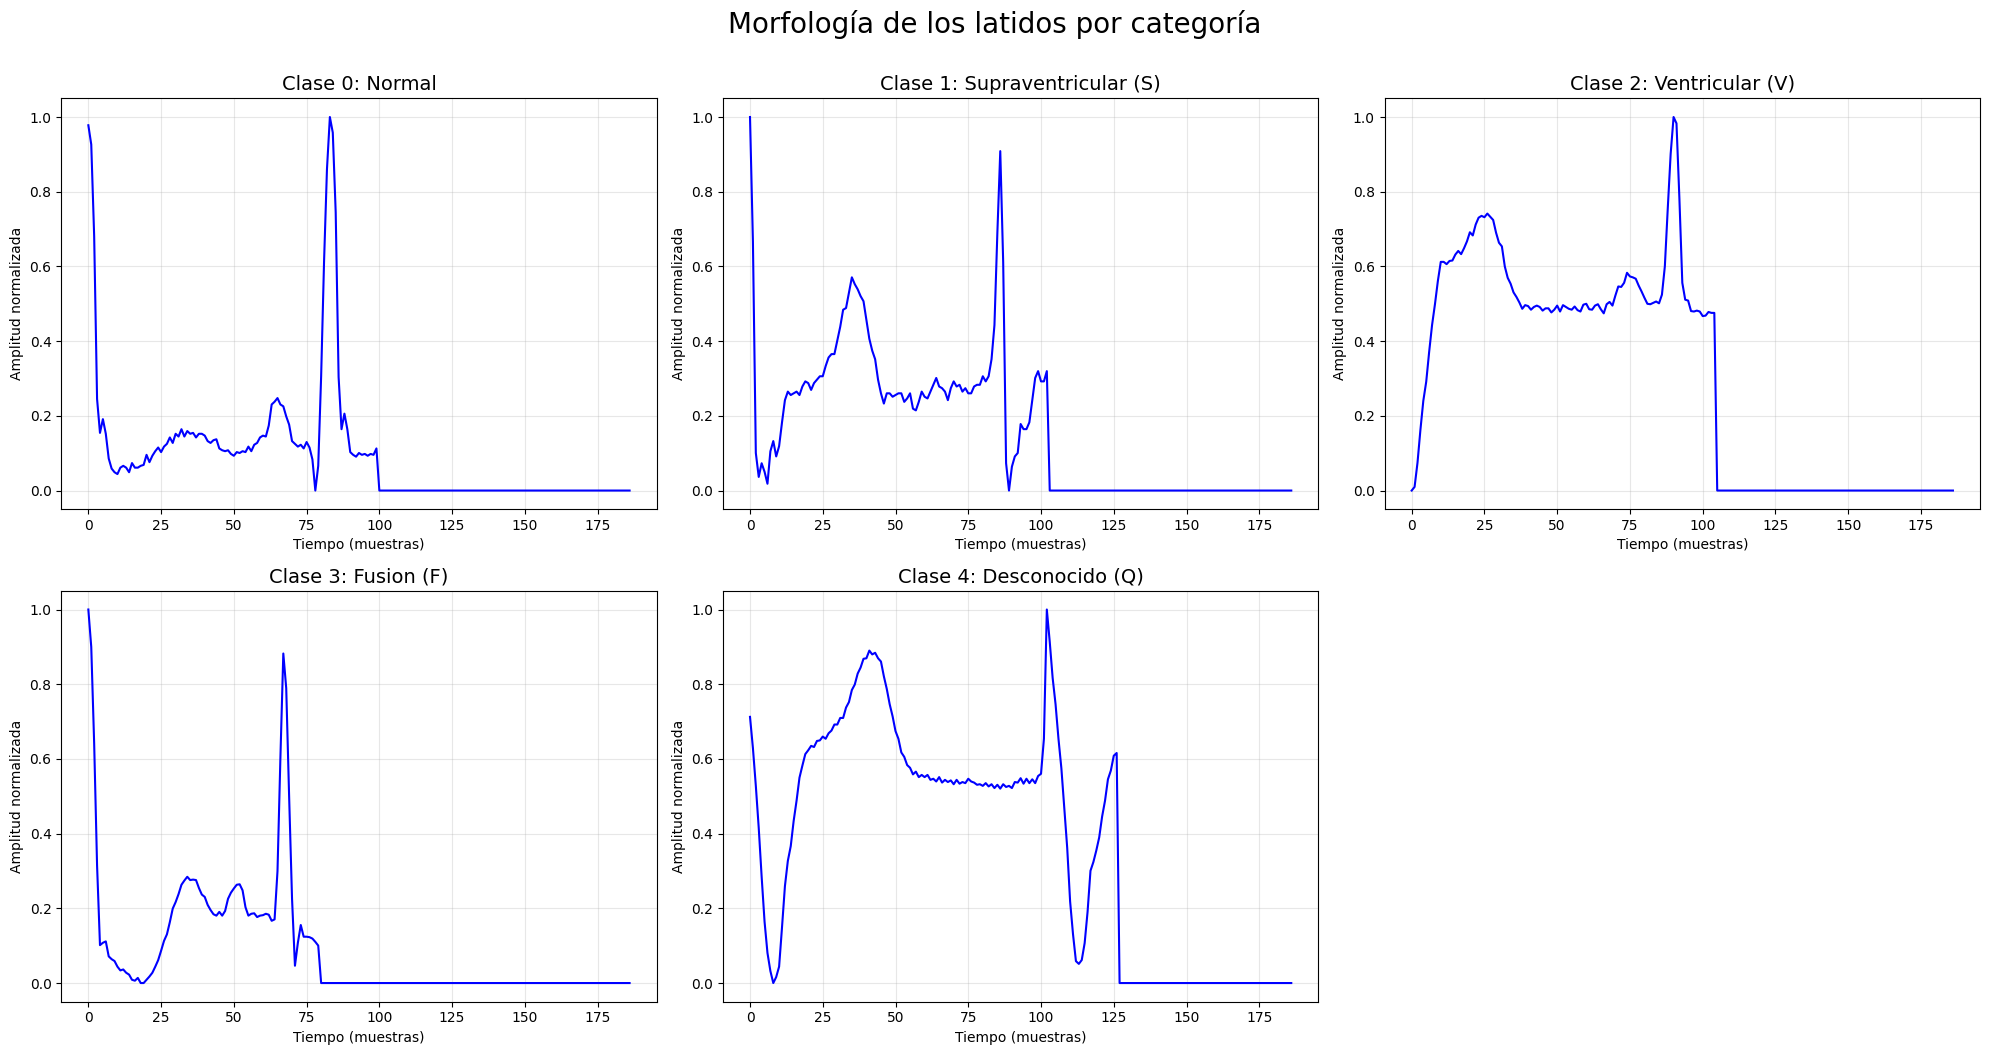

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres de las categorías según la documentación del dataset
classes = {
    0: "Normal",
    1: "Supraventricular (S)",
    2: "Ventricular (V)",
    3: "Fusion (F)",
    4: "Desconocido (Q)"
}

# Acceder a los datos crudos a través del DataModule
train_df = pd.read_csv(os.path.join(path, 'mitbih_train.csv'), header=None)

plt.figure(figsize=(20, 10))

for i in range(5):
    # Seleccionar el primer latido que pertenezca a la clase i(de la columna de etiquetas)
    sample = train_df[train_df[187] == i].iloc[0, :187]

    plt.subplot(2, 3, i + 1)
    plt.plot(sample, color='blue')
    plt.title(f"Clase {i}: {classes[i]}", fontsize=14)
    plt.xlabel("Tiempo (muestras)")
    plt.ylabel("Amplitud normalizada")
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("Morfología de los latidos por categoría", fontsize=20, y=1.05)
plt.show()

**verificar el balanceo de la distribucion de clases**

In [ ]:
counts = train_df[187].value_counts().sort_index()
total = len(train_df)

print("Distribución de clases:")
for i, count in counts.items():
    percentage = (count / total) * 100
    print(f"- {classes[i]}: {count} muestras ({percentage:.2f}%)")

Distribución de clases:
- Normal: 72471 muestras (82.77%)
- Supraventricular (S): 2223 muestras (2.54%)
- Ventricular (V): 5788 muestras (6.61%)
- Fusion (F): 641 muestras (0.73%)
- Desconocido (Q): 6431 muestras (7.35%)


balanciar datos dado que la inmensa  clase Normal ocupa mas del 80% de los datos

In [ ]:
from sklearn.utils import resample

def balance_data(df):
    # Separar las clases
    df_0 = df[df[187] == 0]
    df_1 = df[df[187] == 1]
    df_2 = df[df[187] == 2]
    df_3 = df[df[187] == 3]
    df_4 = df[df[187] == 4]

    # Número de muestras objetivo
    n_samples = len(df_0)

    # Sobremuestreo de las clases minoritarias
    df_1_upsampled = resample(df_1, replace=True, n_samples=n_samples, random_state=42)
    df_2_upsampled = resample(df_2, replace=True, n_samples=n_samples, random_state=42)
    df_3_upsampled = resample(df_3, replace=True, n_samples=n_samples, random_state=42)
    df_4_upsampled = resample(df_4, replace=True, n_samples=n_samples, random_state=42)

    # Combinar de nuevo
    df_balanced = pd.concat([df_0, df_1_upsampled, df_2_upsampled, df_3_upsampled, df_4_upsampled])

    return df_balanced

# Aplicar solo al entrenamiento
train_df_balanced = balance_data(train_df)

print("Nueva distribución de clases en Entrenamiento:")
print(train_df_balanced[187].value_counts())

Nueva distribución de clases en Entrenamiento:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [ ]:
!pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 18.8 MB/s eta 0:00:00


**Modelo base con ROCKET**

Para establecer un punto de referencia (baseline) de rendimiento, se ha seleccionado el algoritmo ROCKET (RandOm Convolutional KEYnel Transform). La elección se debe a su capacidad para clasificar series temporales con un coste computacional mínimo.

In [ ]:

from sktime.classification.kernel_based import RocketClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

# 1. Preparación de datos con SUBMUESTREO
# Entrenar con 15,000 muestras aleatorias
train_sub = train_df_balanced.sample(n=15000, random_state=42)

X_train_rock = train_sub.iloc[:, :187].values[:, np.newaxis, :]
y_train_rock = train_sub.iloc[:, 187].values

# El test lo dejo completo
X_test_rock = test_df.iloc[:, :187].values[:, np.newaxis, :]
y_test_rock = test_df.iloc[:, 187].values

# 2. Configuración y entrenamiento
rocket = RocketClassifier(num_kernels=1000, random_state=42, n_jobs=-1)# corre solo en CPU

print("Entrenando ROCKET optimizado")
%time rocket.fit(X_train_rock, y_train_rock)

# 3. Predicciones
print("Realizando predicciones...")
y_pred_rock = rocket.predict(X_test_rock)
f1_rock = f1_score(y_test_rock, y_pred_rock, average='macro')

print(f"\n ROCKET Finalizado con éxito.")
print(f"F1-Score de ROCKET: {f1_rock:.4f}")
print("--- Reporte de Clasificación Detallado - ROCKET (Baseline) ---")
# Definicion de los nombres de las clases
target_names = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusión (F)', 'Desconocido (Q)']

print(classification_report(y_test_rock, y_pred_rock, target_names=target_names))

Entrenando ROCKET optimizado
CPU times: user 2min 38s, sys: 2.79 s, total: 2min 41s
Wall time: 1min 40s
Realizando predicciones...

 ROCKET Finalizado con éxito.
F1-Score de ROCKET: 0.7555
--- Reporte de Clasificación Detallado - ROCKET (Baseline) ---
                      precision    recall  f1-score   support

          Normal (N)       0.99      0.93      0.96     18118
Supraventricular (S)       0.40      0.87      0.55       556
     Ventricular (V)       0.90      0.95      0.92      1448
          Fusión (F)       0.24      0.94      0.38       162
     Desconocido (Q)       0.96      0.99      0.97      1608

            accuracy                           0.93     21892
           macro avg       0.70      0.93      0.76     21892
        weighted avg       0.96      0.93      0.94     21892



In [ ]:
pip install fastai

**Definición de la Arquitectura InceptionTime**

Tras establecer el baseline, se implementa InceptionTime, una red neuronal profunda diseñada específicamente para la clasificación de series temporales (TSC)

In [ ]:
import torch
import torch.nn as nn

# El Bloque Base
class InceptionModule(nn.Module):
    def __init__(self, in_channels, n_filters, kernel_sizes=[9, 19, 39], bottleneck_channels=32):
        super(InceptionModule, self).__init__()

        # Capa Bottleneck para reducir dimensionalidad y coste computacional
        if in_channels > 1:
            self.bottleneck = nn.Conv1d(in_channels, bottleneck_channels, kernel_size=1, bias=False)
        else:
            self.bottleneck = nn.Identity()
            bottleneck_channels = in_channels

        # Convoluciones en paralelo con diferentes tamaños de kernel
        self.convs = nn.ModuleList()
        for k_size in kernel_sizes:
            self.convs.append(nn.Conv1d(bottleneck_channels, n_filters, kernel_size=k_size, padding='same', bias=False))

        # Rama de MaxPool
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=1, padding=1)
        self.maxpool_conv = nn.Conv1d(in_channels, n_filters, kernel_size=1, bias=False)

        # Post-procesado del bloque
        self.batchnorm = nn.BatchNorm1d(n_filters * (len(kernel_sizes) + 1))
        self.relu = nn.ReLU()

    def forward(self, x):
        # Guardar la x original para la rama del MaxPool
        x_in = x
        x = self.bottleneck(x)

        # Concatenar las salidas de las convoluciones y del maxpool
        conv_outputs = [conv(x) for conv in self.convs]
        maxpool_output = self.maxpool_conv(self.maxpool(x_in))

        outputs = torch.cat(conv_outputs + [maxpool_output], dim=1)
        return self.relu(self.batchnorm(outputs))

# La Red Completa (InceptionTime)
class InceptionTime(nn.Module):
    def __init__(self, n_classes=5, in_channels=1, n_filters=32, n_modules=3):
        super(InceptionTime, self).__init__()

        self.modules_list = nn.ModuleList()
        curr_in_channels = in_channels

        for i in range(n_modules):
            self.modules_list.append(InceptionModule(curr_in_channels, n_filters))
            # La salida de un bloque tiene n_filters * 4 canales (3 convs + 1 maxpool)
            curr_in_channels = n_filters * 4

        # Atajo residual (Shortcut) para conectar entrada con salida del bloque
        self.shortcut = nn.Sequential(
            nn.Conv1d(in_channels, curr_in_channels, kernel_size=1, bias=False),
            nn.BatchNorm1d(curr_in_channels)
        )

        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(curr_in_channels, n_classes)

    def forward(self, x):
        res = self.shortcut(x)

        for mod in self.modules_list:
            x = mod(x)

        # Sumar la conexión residual antes de la clasificación
        x = x + res
        x = self.global_avg_pool(x).squeeze(-1)
        return self.fc(x)

**Entrenamiento y Selección de Hiperparámetros**

Buscando la tasa de aprendizaje óptima...


<div></div>

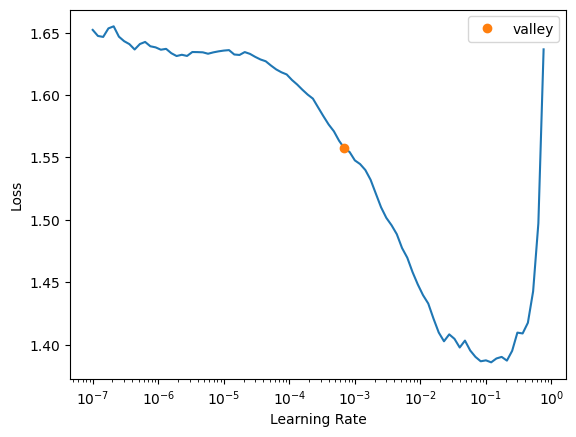

In [ ]:
from fastai.metrics import accuracy, F1Score
from fastai.basics import CrossEntropyLossFlat, Learner, DataLoaders
from fastai.callback.schedule import lr_find
import torch
from functools import partial

# 1. Preparar los DataLoaders de fastai usando el DataFrame balanceado
# Convertir el DataFrame a tensores (X: señal, y: etiqueta)
X_train = torch.FloatTensor(train_df_balanced.iloc[:, :-1].values).unsqueeze(1)
y_train = torch.LongTensor(train_df_balanced.iloc[:, -1].values)

# El test lo dejamos con los datos originales (sin balancear) para una evaluación real
df_test = pd.read_csv(os.path.join(path, 'mitbih_test.csv'), header=None)
X_test = torch.FloatTensor(df_test.iloc[:, :-1].values).unsqueeze(1)
y_test = torch.LongTensor(df_test.iloc[:, -1].values)

# Crear Datasets y DataLoaders
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)
dls = DataLoaders.from_dsets(train_ds, test_ds, bs=64, device=torch.device('cuda'))

# 2. Instanciar el modelo y el Learner
model = InceptionTime(n_classes=5)
learn = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=[accuracy, partial(F1Score, average='macro')])

# 3. Selección del mejor Learning Rate (LR Finder)

print("Buscando la tasa de aprendizaje óptima...")
learn.lr_find()
plt.show()

**Entrenamiento**

In [ ]:
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
    # para asegurar que los DataLoaders usen CUDA
    dls.device = torch.device('cuda')
else:
    print("No se detectó GPU. Revisa la configuración del entorno.")

GPU detectada: Tesla T4


In [ ]:
from fastai.metrics import accuracy, F1Score

# 1. Instanciar el modelo de nuevo
model = InceptionTime(n_classes=5)

# 2. Definir las métricas
# objeto F1Score directamente con la configuración macro
metrics = [accuracy, F1Score(average='macro')]

# 3. configura el Learner
learn = Learner(dls,
                model,
                loss_func=CrossEntropyLossFlat(),
                metrics=metrics)

# 4. Entrenamiento
learn.fit_one_cycle(15, lr_max=1e-3)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,0.200103,0.432538,0.828476,0.746598,01:23
1,0.127897,0.274548,0.905034,0.717706,01:23
2,0.085074,0.205990,0.929061,0.762879,01:23
3,0.067733,0.081643,0.975699,0.892700,01:23
4,0.065057,0.079337,0.975927,0.884613,01:21
5,0.040331,0.078391,0.983007,0.907132,01:21
6,0.029665,0.156150,0.952448,0.850223,01:22
7,0.028521,0.095498,0.973598,0.885481,01:25
8,0.018010,0.068414,0.985200,0.923428,01:25
9,0.016978,0.077023,0.982048,0.914092,01:24


**Evaluacion**

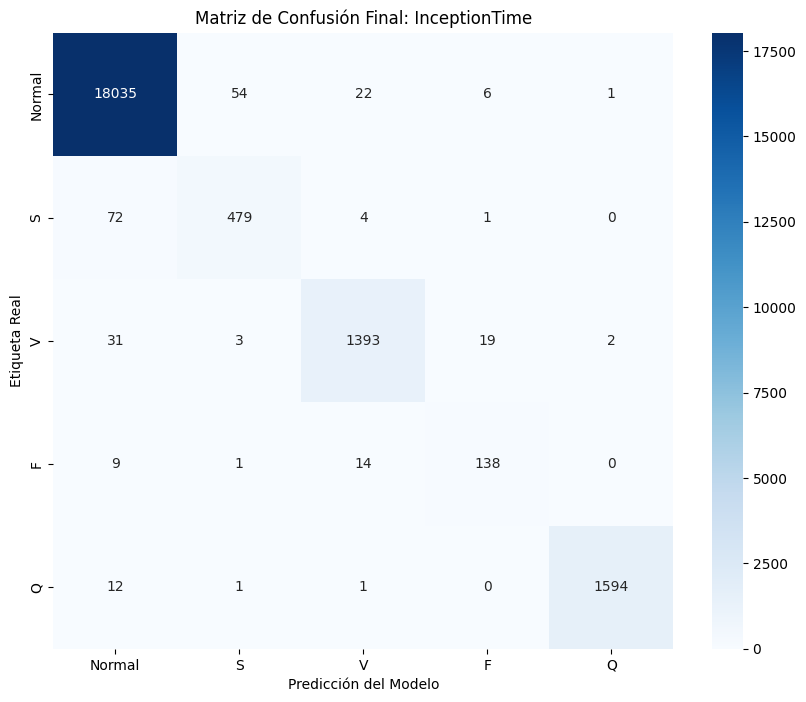


--- Reporte de Clasificación Detallado ---
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     18118
           S       0.89      0.86      0.88       556
           V       0.97      0.96      0.97      1448
           F       0.84      0.85      0.85       162
           Q       1.00      0.99      0.99      1608

    accuracy                           0.99     21892
   macro avg       0.94      0.93      0.94     21892
weighted avg       0.99      0.99      0.99     21892



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Obtener predicciones y etiquetas reales directamente del learner

preds, targs = learn.get_preds(ds_idx=1)

# 2. Convertir a etiquetas
y_pred = np.argmax(preds.numpy(), axis=1)
y_true = targs.numpy()

# 3. Definir nombres de las clases
class_names = ["Normal", "S", "V", "F", "Q"]

# 4. Crear la Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión Final: InceptionTime')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# 5. Imprimir el reporte detallado
print("\n--- Reporte de Clasificación Detallado ---")
print(classification_report(y_true, y_pred, target_names=class_names))

**comparacion de metricas entre ROCKET y InceptionTime**

RESUMEN DE ITERACIONES Y SELECCIÓN DE MODELO


,Modelo,F1-Score (Macro),Accuracy Global,Tiempo de Cálculo,Recurso Usado
0,ROCKET (Baseline),0.755500,-,1min 46s (CPU),CPU (Multi-core)
1,InceptionTime,0.940000,0.99,~15-20 min (GPU),GPU (NVIDIA T4)


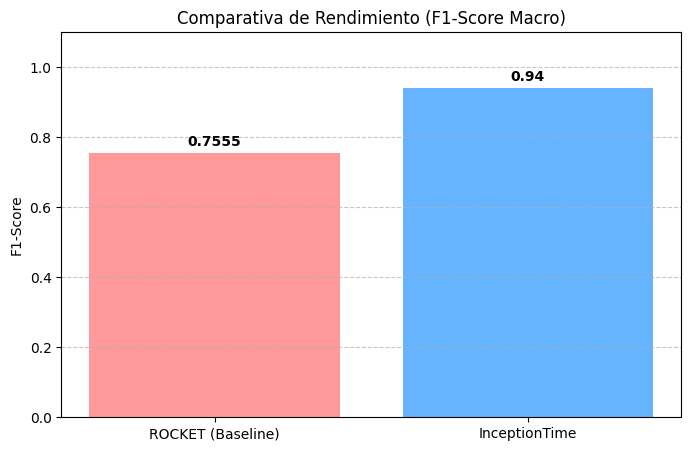

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Datos extraídos
data = {
    'Modelo': ['ROCKET (Baseline)', 'InceptionTime'],
    'F1-Score (Macro)': [0.7555, 0.9400], # resultado de 1000 kernels vs InceptionTime
    'Accuracy Global': ['-', '0.99'],
    'Tiempo de Cálculo': ['1min 46s (CPU)', '~15-20 min (GPU)'],
    'Recurso Usado': ['CPU (Multi-core)', 'GPU (NVIDIA T4)']
}

df_final = pd.DataFrame(data)

# Mostrar tabla
print("RESUMEN DE ITERACIONES Y SELECCIÓN DE MODELO")
display(df_final.style.background_gradient(cmap='Blues', subset=['F1-Score (Macro)']))

# Gráfico de barras para visualizar
plt.figure(figsize=(8, 5))
colores = ['#ff9999','#66b3ff']
plt.bar(df_final['Modelo'], df_final['F1-Score (Macro)'], color=colores)
plt.title('Comparativa de Rendimiento (F1-Score Macro)')
plt.ylabel('F1-Score')
plt.ylim(0, 1.1)

# etiquetas de valor sobre las barras
for i, v in enumerate(df_final['F1-Score (Macro)']):
    plt.text(i, v + 0.02, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Analisis tecnico**

Los resultados obtenidos muestran que, mientras ROCKET ofrece una gran eficiencia computacional y un rendimiento competitivo (F1: 0.76), InceptionTime alcanza un desempeño significativamente superior (F1: 0.94), destacando especialmente en la detección de latidos supraventriculares (S) y de fusión (F), que suelen ser más difíciles de clasificar.

Desde un punto de vista técnico, esta mejora puede explicarse por la arquitectura de InceptionTime, basada en convoluciones a múltiples escalas. El uso de kernels de distintos tamaños en paralelo permite capturar patrones temporales tanto locales como globales en la señal ECG, lo cual resulta clave para identificar variaciones morfológicas complejas.

En contraste, aunque ROCKET es altamente eficiente y sorprendentemente competitivo, su enfoque basado en transformaciones aleatorias puede no capturar con la misma precisión estructuras específicas del dominio. Por tanto, los resultados reflejan un claro compromiso entre eficiencia computacional y capacidad de representación, donde InceptionTime, apoyado además por el uso de GPU, logra un modelo más robusto y adecuado para aplicaciones de diagnóstico clínico.